# GWAS: PLINK (linear) vs GEMMA (LMM)

Runs both methods on 1000 Genomes chr22, then compares with QQ plots, Manhattan plots, and scatter plots. Need the chr22 VCF in `data/` or project root, plus PLINK and GEMMA installed (see README).

## 1. Setup and paths

In [1]:
import os
import subprocess
import shutil
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_ROOT = os.getcwd()
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
OUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
VCF_FILENAME = "ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"
VCF_CHR22 = os.path.join(DATA_DIR, VCF_FILENAME)
if not os.path.isfile(VCF_CHR22):
    VCF_CHR22 = os.path.join(PROJECT_ROOT, VCF_FILENAME)

USE_QUICK_RUN = True
# Subset size: "1mb" = quick test (~1 min), "5mb" = larger benchmark, still runnable on a laptop
SUBSET_SIZE = "5mb"
SUBSET_REGIONS = {
    "1mb": ("22:20000000-21000000", "chr22_1mb"),   # 1 Mb
    "5mb": ("22:20000000-25000000", "chr22_5mb"),   # 5 Mb
}
SUBSET_REGION, SUBSET_LABEL = SUBSET_REGIONS.get(SUBSET_SIZE, ("22:20000000-21000000", "chr22_1mb"))
SUBSET_VCF = os.path.join(DATA_DIR, SUBSET_LABEL + ".vcf.gz")
PLINK_PREFIX = os.path.join(OUT_DIR, SUBSET_LABEL if USE_QUICK_RUN else "chr22_1kg")
VCF_TO_USE = VCF_CHR22 

PLINK_PATH = "/Users/colecarter/Downloads/plink2_mac_20260228/plink2"
GEMMA_PATH = "/Users/colecarter/GEMMA/bin/gemma"

def find_cmd(name, common_paths):
    out = shutil.which(name)
    if out:
        return out
    for p in common_paths:
        if os.path.isfile(p) and os.access(p, os.X_OK):
            return p
    return name

PLINK_CMD = PLINK_PATH if (PLINK_PATH and os.path.isfile(PLINK_PATH)) else find_cmd("plink", [
    "/opt/homebrew/bin/plink", "/usr/local/bin/plink",
    os.path.expanduser("~/bin/plink"),
])
GEMMA_CMD = GEMMA_PATH if (GEMMA_PATH and os.path.isfile(GEMMA_PATH)) else find_cmd("gemma", [
    "/opt/homebrew/bin/gemma", "/usr/local/bin/gemma",
    os.path.expanduser("~/bin/gemma"),
])
print("PLINK:", PLINK_CMD)
print("GEMMA:", GEMMA_CMD)
import sys
if sys.platform == "darwin" and "linux" in (PLINK_CMD or "").lower():
    raise SystemError("Use the macOS build of PLINK, not the linux one. Set PLINK_PATH to the plink2 binary.")
if PLINK_CMD == "plink":
    print("Set PLINK_PATH to your plink2 path if you installed it manually.")
if GEMMA_CMD == "gemma":
    print("GEMMA not found; install it or set GEMMA_PATH.")

for d in (DATA_DIR, OUT_DIR):
    os.makedirs(d, exist_ok=True)
print("Data dir:", DATA_DIR)
print("Output dir:", OUT_DIR)
print("Quick run:", USE_QUICK_RUN, f"({SUBSET_SIZE})" if USE_QUICK_RUN else "")
print("VCF path:", VCF_CHR22)
print("VCF exists:", os.path.isfile(VCF_CHR22))

PLINK: /Users/colecarter/Downloads/plink2_mac_20260228/plink2
GEMMA: /Users/colecarter/GEMMA/bin/gemma
Data dir: /Users/colecarter/CSE284Project/data
Output dir: /Users/colecarter/CSE284Project/outputs
Quick run: True (5mb)
VCF path: /Users/colecarter/CSE284Project/data/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz
VCF exists: True


## 1b. Quick run: create subset (1 Mb or 5 Mb)

If USE_QUICK_RUN is True, this builds a VCF for the region set by **SUBSET_SIZE** ("1mb" or "5mb"). 1 Mb runs in under a minute; 5 Mb is larger so the benchmark comparison is on a non-trivial amount of data while still runnable on a laptop.

**Presentation:** Use **5mb** and say: *"We used a 5 Mb region of chr22 so the PLINK vs GEMMA comparison is on a substantial number of SNPs and samples, while still completing in a few minutes so we could iterate and demo on a laptop."* Need bcftools or pysam.

In [2]:
if not USE_QUICK_RUN:
    VCF_TO_USE = VCF_CHR22
    print("Using full chr22 VCF (this will be slow).")
else:
    if os.path.isfile(SUBSET_VCF):
        VCF_TO_USE = SUBSET_VCF
        print("Subset already exists:", SUBSET_VCF)
    else:
        bcftools = shutil.which("bcftools")
        if bcftools:
            t0 = time.time()
            r = subprocess.run([
                bcftools, "view", "-r", SUBSET_REGION, "-Oz", "-o", SUBSET_VCF,
                VCF_CHR22,
            ], capture_output=True, text=True, timeout=600)
            if r.returncode != 0:
                print("bcftools stderr:", r.stderr)
                if "index" in (r.stderr or "").lower() or "idx_find" in (r.stderr or ""):
                    raise RuntimeError(
                        "VCF index (.tbi) missing. Download it and put next to your VCF:\n"
                        "  curl -O https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi"
                    )
                raise RuntimeError("bcftools subset failed")
            print(f"Subset created in {time.time()-t0:.1f} s with bcftools")
            VCF_TO_USE = SUBSET_VCF
        else:
            try:
                import pysam
                # Parse SUBSET_REGION (e.g. "22:20000000-25000000") for pysam fetch
                _chr, _range = SUBSET_REGION.split(":")
                _start, _end = map(int, _range.split("-"))
                subset_plain = os.path.join(DATA_DIR, SUBSET_LABEL + ".vcf")
                t0 = time.time()
                with pysam.VariantFile(VCF_CHR22) as invcf, \
                     pysam.VariantFile(subset_plain, "w", header=invcf.header) as outvcf:
                    for rec in invcf.fetch(_chr, _start, _end):
                        outvcf.write(rec)
                print(f"Subset created in {time.time()-t0:.1f} s with pysam")
                VCF_TO_USE = subset_plain
            except ModuleNotFoundError:
                raise ModuleNotFoundError(
                    "Need bcftools (brew install bcftools) or pysam (pip install pysam), then re-run."
                ) from None
            except Exception as e:
                print("Subset failed:", e)
                raise
    PLINK_PREFIX = os.path.join(OUT_DIR, SUBSET_LABEL)
print("VCF_TO_USE:", VCF_TO_USE)
print("PLINK_PREFIX:", PLINK_PREFIX)

Subset already exists: /Users/colecarter/CSE284Project/data/chr22_5mb.vcf.gz
VCF_TO_USE: /Users/colecarter/CSE284Project/data/chr22_5mb.vcf.gz
PLINK_PREFIX: /Users/colecarter/CSE284Project/outputs/chr22_5mb


## 2. Convert VCF to PLINK binary

Uses the VCF you have (data/ or project root). Conversion can take a while on full chr22; quick run is much faster.

In [3]:
if not os.path.isfile(VCF_TO_USE):
    raise FileNotFoundError(
        "VCF not found. For full chr22 use the full VCF; for quick run run the 'Create subset' cell first."
    )

# Convert VCF to PLINK binary (only if not already done)
if not os.path.isfile(PLINK_PREFIX + ".bed"):
    t0 = time.time()
    cmd = [
        PLINK_CMD, "--vcf", VCF_TO_USE,
        "--chr", "22",
        "--out", PLINK_PREFIX,
        "--make-bed",
        "--allow-extra-chr",
        "--double-id",
        "--max-alleles", "2",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=3600)
    if result.returncode != 0:
        print("PLINK stderr:", result.stderr)
        print("PLINK stdout:", result.stdout)
        result.check_returncode()
    elif result.stderr:
        print(result.stderr)
    print(f"Conversion time: {time.time() - t0:.1f} s")
else:
    print("PLINK binary already exists, skipping conversion.")

Conversion time: 2.6 s


## 3. Simulated phenotype

1000 Genomes has no traits; using a random quantitative phenotype for the comparison.

In [4]:
fam_path = PLINK_PREFIX + ".fam"
if os.path.isfile(fam_path):
    fam = pd.read_csv(fam_path, sep=r"\s+", header=None,
                      names=["FID", "IID", "father", "mother", "sex", "pheno"])
    n = len(fam)
    np.random.seed(284)
    pheno = np.random.randn(n)  
    pheno_df = fam[["FID", "IID"]].copy()
    pheno_df["pheno"] = pheno
    pheno_file = os.path.join(OUT_DIR, "pheno_quant.txt")
    pheno_df.to_csv(pheno_file, sep="\t", index=False, header=True)
    print(f"Wrote phenotype for {n} samples to {pheno_file}")
else:
    raise FileNotFoundError("Run the VCF→PLINK conversion cell first.")

Wrote phenotype for 2504 samples to /Users/colecarter/CSE284Project/outputs/pheno_quant.txt


## 4. Run PLINK linear regression GWAS

In [5]:
plink_assoc = os.path.join(OUT_DIR, "plink_linear.assoc.linear")
plink_glm = os.path.join(OUT_DIR, "plink_linear.glm.linear")  # PLINK 2 output
t0 = time.time()
subprocess.run([
    PLINK_CMD, "--bfile", PLINK_PREFIX,
    "--pheno", pheno_file,
    "--glm", "allow-no-covars", "hide-covar",
    "--out", os.path.join(OUT_DIR, "plink_linear"),
    "--allow-extra-chr",
], check=True, cwd=OUT_DIR)
plink_time = time.time() - t0
print(f"PLINK GWAS finished in {plink_time:.1f} s")

PLINK v2.0.0-a.7 64-bit (28 Feb 2026)               cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to /Users/colecarter/CSE284Project/outputs/plink_linear.log.
Options in effect:
  --allow-extra-chr
  --bfile /Users/colecarter/CSE284Project/outputs/chr22_5mb
  --glm allow-no-covars hide-covar
  --out /Users/colecarter/CSE284Project/outputs/plink_linear
  --pheno /Users/colecarter/CSE284Project/outputs/pheno_quant.txt

Start time: Mon Mar  9 19:06:13 2026
16384 MiB RAM detected; reserving 8192 MiB for main workspace.
Using up to 12 threads (change this with --threads).
2504 samples (0 females, 0 males, 2504 ambiguous; 2504 founders) loaded from
/Users/colecarter/CSE284Project/outputs/chr22_5mb.fam.
145352 variants loaded from
/Users/colecarter/CSE284Project/outputs/chr22_5mb.bim.
1 quantitative phenotype loaded (2504 values).
Calculating allele frequencies... 4590done.
--glm linear regression on phenotype 'pheno': 4590

## 5. Run GEMMA (LMM) GWAS

GEMMA needs a relatedness matrix. We compute it from the same genotypes, then run the association.

In [6]:
gemma_cwd = OUT_DIR
bfile_base = os.path.basename(PLINK_PREFIX)
if GEMMA_CMD == "gemma" or not os.path.isfile(GEMMA_CMD):
    print("GEMMA not found; skipping LMM. Only PLINK results will be plotted.")
else:
    # GEMMA needs non-missing phenotype in .fam (else "0 individuals")
    fam_path = PLINK_PREFIX + ".fam"
    fam = pd.read_csv(fam_path, sep=r"\s+", header=None)
    fam[5] = pheno_df["pheno"].values
    fam.to_csv(fam_path, sep="\t", index=False, header=False)
    t0 = time.time()
    rc = subprocess.run([
        GEMMA_CMD, "-bfile", bfile_base,
        "-gk", "1",
        "-o", "relatedness",
    ], cwd=gemma_cwd, capture_output=True, text=True)
    if rc.returncode != 0:
        print("GEMMA stdout:", rc.stdout)
        print("GEMMA stderr:", rc.stderr)
        print("returncode:", rc.returncode)
    rc.check_returncode()
    print(f"Relatedness matrix computed in {time.time() - t0:.1f} s")

Relatedness matrix computed in 11.0 s


In [7]:
if GEMMA_CMD != "gemma" and os.path.isfile(GEMMA_CMD):
    fam = pd.read_csv(PLINK_PREFIX + ".fam", sep=r"\s+", header=None)
    pheno_only = os.path.join(OUT_DIR, "pheno_gemma.txt")
    fam[5] = pheno_df["pheno"].values
    fam[[5]].to_csv(pheno_only, sep="\t", index=False, header=False)
    t0 = time.time()
    subprocess.run([
        GEMMA_CMD, "-bfile", bfile_base,
        "-k", "output/relatedness.cXX.txt",
        "-p", "pheno_gemma.txt",
        "-lmm", "4",
        "-o", "gemma_lmm",
    ], cwd=gemma_cwd, check=True)
    gemma_time = time.time() - t0
    print(f"GEMMA LMM GWAS finished in {gemma_time:.1f} s")
else:
    print("GEMMA skipped (not installed).")

GEMMA 0.98.6 (2022-08-05) by Xiang Zhou, Pjotr Prins and team (C) 2012-2022
Reading Files ... 
## number of total individuals = 2504
## number of analyzed individuals = 2504
## number of covariates = 1
## number of phenotypes = 1
## number of total SNPs/var        =   145352
## number of analyzed SNPs         =    26321
Start Eigen-Decomposition...
pve estimate =2.30543e-06
se(pve) =0.0450926
================================================== 100%
GEMMA LMM GWAS finished in 54.5 s


**** INFO: Done.


## 6. Load association results

In [8]:
# PLINK 2 writes .glm.linear; PLINK 1.9 writes .assoc.linear
if os.path.isfile(plink_glm):
    plink_raw = pd.read_csv(plink_glm, sep=r"\s+")
    plink_df = plink_raw[["#CHROM", "ID", "POS", "A1", "BETA", "P"]].copy()
    plink_df = plink_df.rename(columns={"#CHROM": "CHR", "ID": "SNP", "POS": "BP", "P": "P_plink", "BETA": "BETA_plink"})
else:
    plink_raw = pd.read_csv(plink_assoc, sep=r"\s+")
    plink_df = plink_raw[plink_raw["TEST"] == "ADD"][["CHR", "SNP", "BP", "A1", "BETA", "STAT", "P"]].copy()
    plink_df = plink_df.rename(columns={"P": "P_plink", "BETA": "BETA_plink"})
print("PLINK:", plink_df.shape[0], "SNPs")

gemma_assoc = os.path.join(OUT_DIR, "output", "gemma_lmm.assoc.txt")
if os.path.isfile(gemma_assoc):
    gemma_df = pd.read_csv(gemma_assoc, sep="\t")
    # columns: chr, rs, ps, n_miss, allele1, allele2, af, beta, se, l_reml, p_wald (or p_lrt)
    gemma_df = gemma_df.rename(columns={"ps": "BP", "rs": "SNP", "p_wald": "P_gemma", "beta": "BETA_gemma"})
    if "P_gemma" not in gemma_df.columns:
        gemma_df["P_gemma"] = gemma_df.get("p_lrt", gemma_df.get("p_wald", np.nan))
    print("GEMMA: ", gemma_df.shape[0], "SNPs")
else:
    gemma_df = None
    print("GEMMA output not found; run GEMMA cell first.")

PLINK: 5000 SNPs
GEMMA:  26321 SNPs


## 7. QQ plots

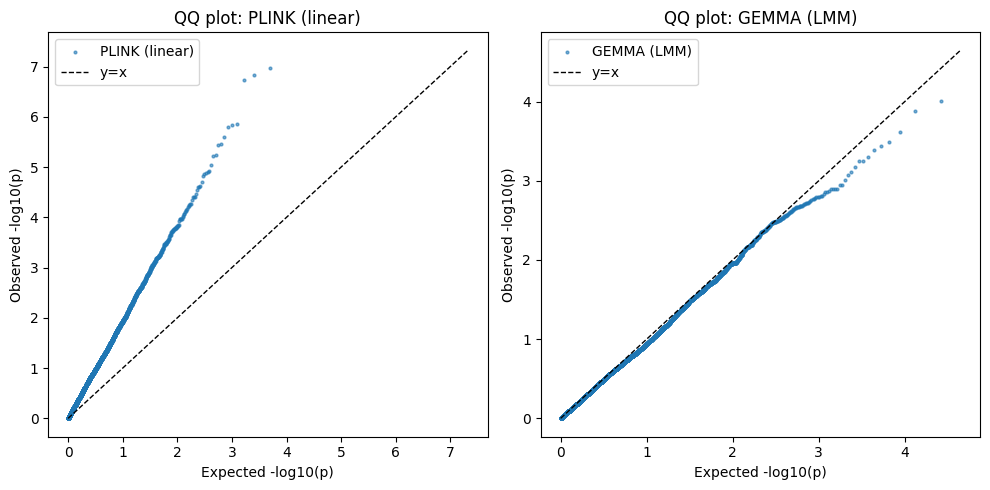

In [9]:
def qq_plot(p_values, label, ax):
    p = np.array(p_values).flatten()
    p = p[~(p <= 0)]
    p = np.sort(p)
    n = len(p)
    expected = -np.log10(np.linspace(1 / (n + 1), n / (n + 1), n))
    observed = -np.log10(p)
    ax.scatter(expected, observed, s=4, alpha=0.6, label=label)
    lim = max(expected.max(), observed.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1, label="y=x")
    ax.set_xlabel("Expected -log10(p)")
    ax.set_ylabel("Observed -log10(p)")
    ax.legend()
    ax.set_title(f"QQ plot: {label}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
qq_plot(plink_df["P_plink"], "PLINK (linear)", axes[0])
if gemma_df is not None:
    qq_plot(gemma_df["P_gemma"], "GEMMA (LMM)", axes[1])
else:
    axes[1].set_title("GEMMA (LMM) — no results")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "qq_plink_vs_gemma.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Manhattan plots

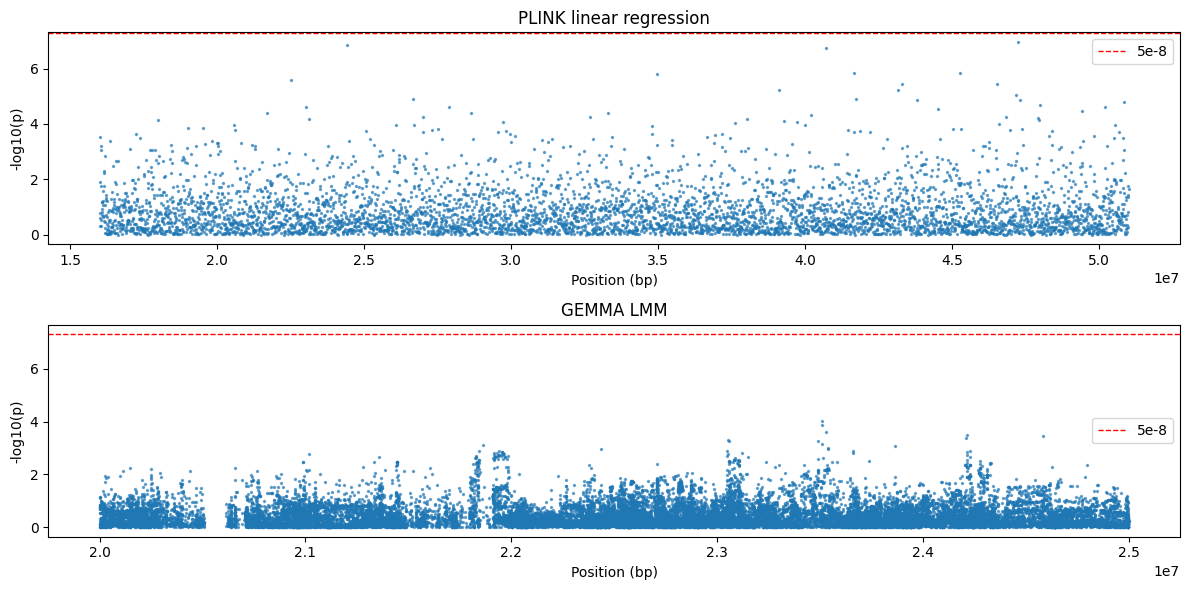

In [10]:
def manhattan(p_df, p_col, title, ax):
    p_df = p_df.copy()
    p_df["log10p"] = -np.log10(p_df[p_col].clip(lower=1e-300))
    ax.scatter(p_df["BP"], p_df["log10p"], s=2, alpha=0.6)
    ax.axhline(-np.log10(5e-8), color="red", linestyle="--", linewidth=1, label="5e-8")
    ax.set_xlabel("Position (bp)")
    ax.set_ylabel("-log10(p)")
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
manhattan(plink_df, "P_plink", "PLINK linear regression", axes[0])
if gemma_df is not None:
    manhattan(gemma_df, "P_gemma", "GEMMA LMM", axes[1])
else:
    axes[1].set_title("GEMMA LMM — no results")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "manhattan_plink_vs_gemma.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9. Scatter: PLINK vs GEMMA p-values (and effect sizes)

Merge results by SNP/position to compare concordance.

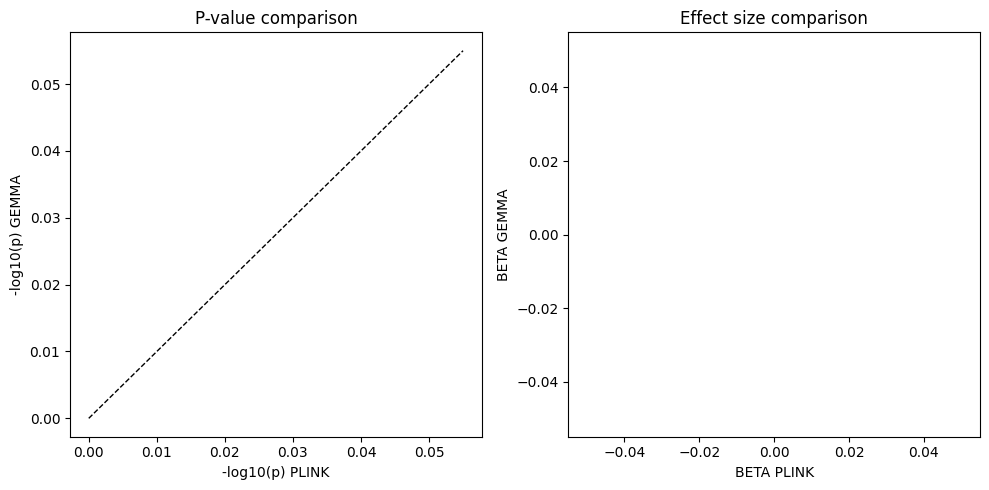

In [11]:
if gemma_df is not None:
    # Merge by position (BP); SNP IDs often don't match between PLINK 2 (e.g. ".") and GEMMA (rs IDs)
    m = plink_df.merge(
        gemma_df[["BP", "P_gemma", "BETA_gemma"]].drop_duplicates(subset=["BP"]),
        on="BP", how="inner"
    )
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].scatter(-np.log10(m["P_plink"].clip(1e-300)), -np.log10(m["P_gemma"].clip(1e-300)), s=2, alpha=0.5)
    lim = max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])
    axes[0].plot([0, lim], [0, lim], "k--", lw=1)
    axes[0].set_xlabel("-log10(p) PLINK")
    axes[0].set_ylabel("-log10(p) GEMMA")
    axes[0].set_title("P-value comparison")
    axes[1].scatter(m["BETA_plink"], m["BETA_gemma"], s=2, alpha=0.5)
    axes[1].set_xlabel("BETA PLINK")
    axes[1].set_ylabel("BETA GEMMA")
    axes[1].set_title("Effect size comparison")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "scatter_plink_vs_gemma.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Merge skipped (no GEMMA results).")

## 10. Runtime comparison (optional)

If you ran both tools in this session, we can report runtimes.

In [12]:
try:
    print(f"PLINK linear GWAS: {plink_time:.1f} s")
    print(f"GEMMA LMM GWAS:   {gemma_time:.1f} s")
except NameError:
    print("Rerun the PLINK and GEMMA cells to see runtimes.") 

PLINK linear GWAS: 0.2 s
GEMMA LMM GWAS:   54.5 s
